# Fitness Lifestyle Analysis using Python

## Project Overview
This project analyzes fitness lifestyle survey data collected from 65 participants. The objective is to explore relationships between workout habits, sleep patterns, diet, hydration, and fitness goals using Python (Pandas) and visualize key insights for decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

file_path = r"C:\Users\manas\Downloads\fitness data analytics project\Impact of lifestyle changes on workout consistency\prepare\uncleaned responses.xlsx"

df = pd.read_excel(file_path)

df.head()

,Timestamp,Age Group,How many days per week do you work out?,How many hours do you sleep daily?,What best describes your diet?,Do you skip workouts?,"If yes, what is the main reason?",What is your primary fitness goal?
0,2026-04-28 14:53:28.143,16-22,5+,7+,Mixed,Yes,Feeling Tired,Muscle Gain
1,2026-04-28 14:54:58.105,16-22,5+,5-6,Mixed,No,Other,Muscle Gain
2,2026-04-28 14:55:04.431,23-30,3-4,7+,Healthy,No,Other,Muscle Gain
3,2026-04-28 14:55:39.723,23-30,5+,6-7,Mixed,Yes,Other,General Fitnesss
4,2026-04-28 14:58:55.327,16-22,5+,6-7,Mixed,No,Other,General Fitnesss


In [3]:
df.shape

(65, 8)

In [4]:
df.columns

Index(['Timestamp', 'Age Group', '  How many days per week do you work out?  ',
       '  How many hours do you sleep daily?  ',
       '  What best describes your diet?  ', '  Do you skip workouts?  ',
       '  If yes, what is the main reason?  ',
       '  What is your primary fitness goal?  '],
      dtype='object')

In [5]:
df.info

<bound method DataFrame.info of                  Timestamp Age Group  \
0  2026-04-28 14:53:28.143     16-22   
1  2026-04-28 14:54:58.105     16-22   
2  2026-04-28 14:55:04.431     23-30   
3  2026-04-28 14:55:39.723     23-30   
4  2026-04-28 14:58:55.327     16-22   
..                     ...       ...   
60 2026-05-24 17:10:33.640     16-22   
61 2026-05-24 17:10:48.356     16-22   
62 2026-05-24 17:11:02.780       51+   
63 2026-05-24 17:11:50.362     31-50   
64 2026-05-24 17:12:11.150       51+   

     How many days per week do you work out?    \
0                                           5+   
1                                           5+   
2                                          3-4   
3                                           5+   
4                                           5+   
..                                         ...   
60                                          5+   
61                                          5+   
62                                   

In [6]:

df = df.drop(columns=["Timestamp"])

In [7]:
df.head()

,Age Group,How many days per week do you work out?,How many hours do you sleep daily?,What best describes your diet?,Do you skip workouts?,"If yes, what is the main reason?",What is your primary fitness goal?
0,16-22,5+,7+,Mixed,Yes,Feeling Tired,Muscle Gain
1,16-22,5+,5-6,Mixed,No,Other,Muscle Gain
2,23-30,3-4,7+,Healthy,No,Other,Muscle Gain
3,23-30,5+,6-7,Mixed,Yes,Other,General Fitnesss
4,16-22,5+,6-7,Mixed,No,Other,General Fitnesss


In [8]:
df.shape

(65, 7)

    ## Data Cleaning

Before analyzing the data, the dataset is inspected for missing values, duplicate records, inconsistent data types, and other quality issues.

In [9]:
df.isnull().sum()

Age Group                                       0
  How many days per week do you work out?       0
  How many hours do you sleep daily?            0
  What best describes your diet?                0
  Do you skip workouts?                         0
  If yes, what is the main reason?             19
  What is your primary fitness goal?            0
dtype: int64

In [10]:
df.duplicated().sum()

9

### Duplicate Check

The dataset was checked for duplicate records using Pandas. Although 9 rows were flagged as duplicates after removing the Timestamp column, these records were retained because they likely represent different participants who selected the same combination of survey responses. In survey datasets, identical responses do not necessarily indicate duplicate entries.

In [11]:
df.columns

Index(['Age Group', '  How many days per week do you work out?  ',
       '  How many hours do you sleep daily?  ',
       '  What best describes your diet?  ', '  Do you skip workouts?  ',
       '  If yes, what is the main reason?  ',
       '  What is your primary fitness goal?  '],
      dtype='object')

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df.columns

Index(['Age Group', 'How many days per week do you work out?',
       'How many hours do you sleep daily?', 'What best describes your diet?',
       'Do you skip workouts?', 'If yes, what is the main reason?',
       'What is your primary fitness goal?'],
      dtype='object')

In [14]:
df.rename(columns={
    "Age Group": "age_group",
    "How many days per week do you work out?": "workout_days",
    "How many hours do you sleep daily?": "sleep_hours",
    "What best describes your diet?": "diet",
    "Do you skip workouts?": "skip_workouts",
    "If yes, what is the main reason?": "skip_reason",
    "What is your primary fitness goal?": "fitness_goal"
}, inplace=True)

In [15]:
df.columns

Index(['age_group', 'workout_days', 'sleep_hours', 'diet', 'skip_workouts',
       'skip_reason', 'fitness_goal'],
      dtype='object')

## Exploratory Data Analysis (EDA)

The objective of this analysis is to identify trends and relationships between participants' workout habits, sleep patterns, diet, and fitness goals. The insights generated from this analysis will be used to build an interactive Power BI dashboard.

### 1. Age Group Distribution

This analysis identifies the age groups represented in the survey.

In [16]:
df["age_group"].value_counts()

age_group
16-22    37
23-30    10
31-50     9
51+       9
Name: count, dtype: int64

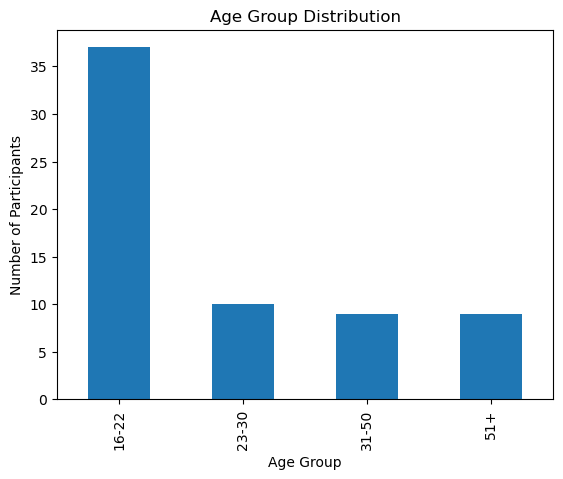

In [17]:
df["age_group"].value_counts().plot(kind="bar")

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Participants")
plt.show()

### 2. Workout Frequency

This analysis examines how many days per week participants exercise.

In [18]:
df["workout_days"].value_counts()

workout_days
5+     23
3-4    19
0      12
1-2    11
Name: count, dtype: int64

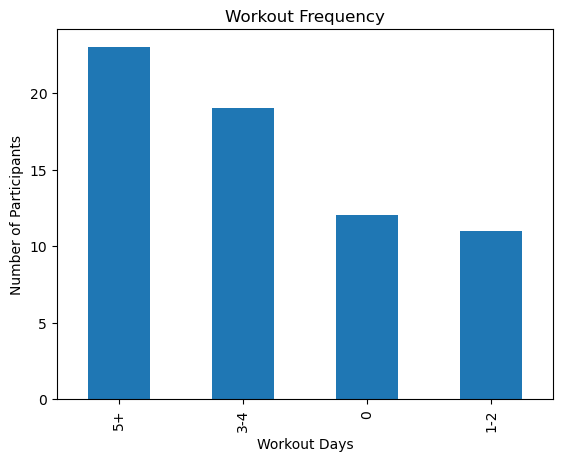

In [19]:
df["workout_days"].value_counts().plot(kind="bar")

plt.title("Workout Frequency")
plt.xlabel("Workout Days")
plt.ylabel("Number of Participants")
plt.show()

### Observation

The majority of participants work out 5+ days per week.

### 3. Sleep Duration Analysis

This analysis examines the average daily sleep duration of participants to understand their sleeping habits. Adequate sleep plays an important role in recovery, physical performance, and maintaining workout consistency. By analyzing the distribution of sleep hours, we can identify common sleep patterns among the survey participants.

In [20]:
df["sleep_hours"].value_counts()

sleep_hours
7+             28
6-7            25
5-6             9
Less than 5     3
Name: count, dtype: int64

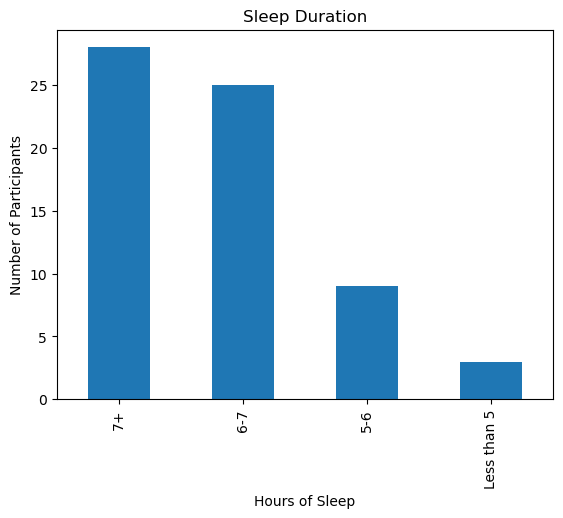

In [21]:
df["sleep_hours"].value_counts().plot(kind="bar")

plt.title("Sleep Duration")
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Participants")
plt.show()

### Observation

The majority of participants reported sleeping 7+ hours per day, indicating that this is the most common sleep duration among the surveyed individuals. This insight will later be compared with workout frequency to explore whether sleep duration influences workout consistency.

## 4. Diet Distribution

This analysis examines the dietary preferences of participants. Understanding diet patterns helps identify the most common nutritional habits and provides context for later comparisons with workout consistency.

In [22]:
df["diet"].value_counts()

diet
Mixed          35
Healthy        21
Mostly Junk     9
Name: count, dtype: int64

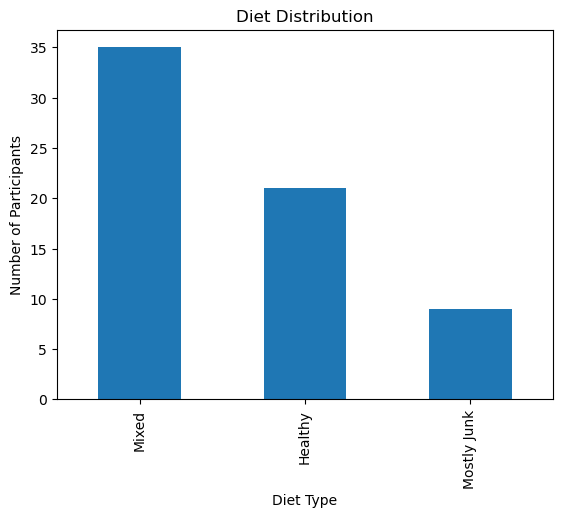

In [23]:
df["diet"].value_counts().plot(kind="bar")

plt.title("Diet Distribution")
plt.xlabel("Diet Type")
plt.ylabel("Number of Participants")
plt.show()

### Observation

The chart shows the distribution of different diet types among participants. The most common diet pattern will later be compared with workout frequency to explore whether dietary habits are associated with exercise consistency.

## 5. Workout Skipping Behaviour

This analysis examines whether participants tend to skip workouts. Understanding this behavior provides insight into overall workout consistency among the respondents.

In [24]:
df["skip_workouts"].value_counts()

skip_workouts
Yes    41
No     24
Name: count, dtype: int64

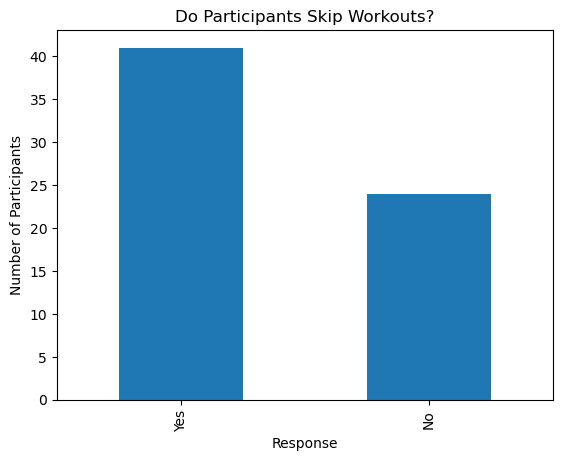

In [25]:
df["skip_workouts"].value_counts().plot(kind="bar")

plt.title("Do Participants Skip Workouts?")
plt.xlabel("Response")
plt.ylabel("Number of Participants")
plt.show()

## 6. Reasons for Skipping Workouts

This analysis identifies the primary reasons participants miss their workouts. Understanding these barriers can help explain workout inconsistency and highlight common challenges faced by individuals.

In [26]:
df["skip_reason"].value_counts()

skip_reason
Feeling Tired     17
Other             11
Lack Of Time      11
Low Motivation     7
Name: count, dtype: int64

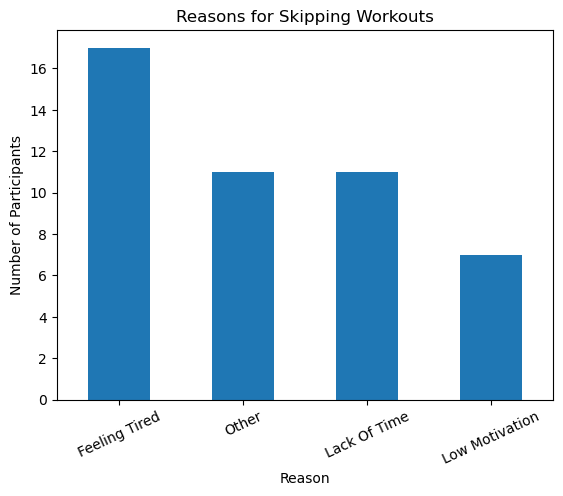

In [27]:
df["skip_reason"].value_counts().plot(kind="bar")

plt.title("Reasons for Skipping Workouts")
plt.xlabel("Reason")
plt.ylabel("Number of Participants")
plt.xticks(rotation=25)
plt.show()

### Observation

The chart highlights the most frequently reported reasons for skipping workouts. Identifying these barriers provides valuable insight into the lifestyle factors that influence exercise consistency.

## 7. Primary Fitness Goal

This analysis explores the primary fitness objectives of participants. Understanding these goals provides context for workout habits and overall lifestyle preferences.

In [28]:
df["fitness_goal"].value_counts()

fitness_goal
General Fitnesss    27
Muscle Gain         24
Weight Loss         14
Name: count, dtype: int64

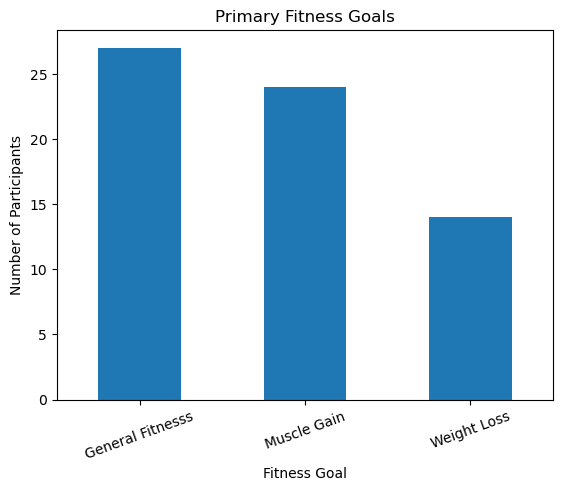

In [29]:
df["fitness_goal"].value_counts().plot(kind="bar")

plt.title("Primary Fitness Goals")
plt.xlabel("Fitness Goal")
plt.ylabel("Number of Participants")
plt.xticks(rotation=20)
plt.show()

### Observation

The chart illustrates the distribution of participants' primary fitness goals, helping identify the most common motivations behind their exercise routines.

# Relationship Analysis

The following analyses explore relationships between different lifestyle factors and workout consistency. Unlike the previous section, which focused on individual variables, this section examines how multiple variables interact to uncover meaningful patterns.

## 1. Sleep Duration vs Workout Frequency

This analysis explores whether participants who sleep longer tend to exercise more frequently. Since adequate sleep supports recovery and physical performance, understanding this relationship may provide insights into workout consistency.

In [30]:
sleep_workout = pd.crosstab(df["sleep_hours"], df["workout_days"])

sleep_workout

workout_days,0,1-2,3-4,5+
sleep_hours,,,,
5-6,3,1,2,3
6-7,5,8,6,6
7+,2,2,10,14
Less than 5,2,0,1,0


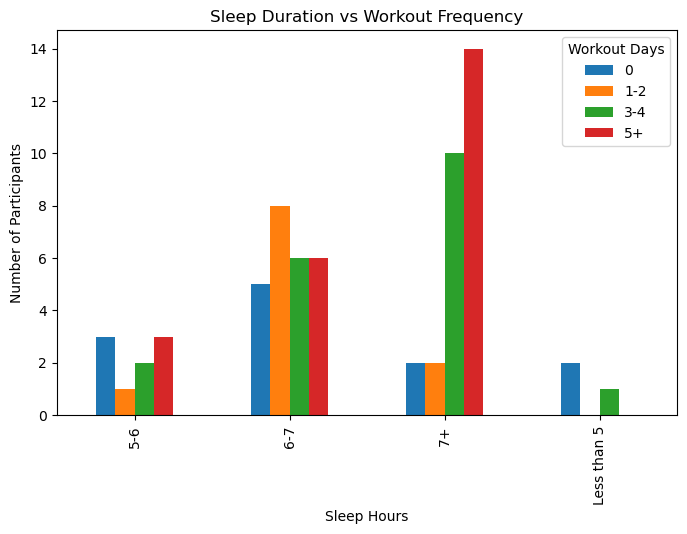

In [31]:
sleep_workout.plot(kind="bar", figsize=(8,5))

plt.title("Sleep Duration vs Workout Frequency")
plt.xlabel("Sleep Hours")
plt.ylabel("Number of Participants")
plt.legend(title="Workout Days")
plt.show()

### Observation

The comparison highlights how workout frequency varies across different sleep duration groups. This helps identify whether participants with longer sleep durations tend to maintain more consistent workout routines.

# Recommendations

Based on the survey findings, the following recommendations can be made:

- Aim for at least 7 hours of sleep to support workout recovery and consistency.
- Maintain a balanced diet alongside regular physical activity.
- Address common workout barriers such as fatigue through proper rest and time management.
- Set clear fitness goals to improve long-term exercise adherence.

## 2. Diet Type vs Workout Frequency

This analysis investigates whether different dietary habits are associated with varying levels of workout consistency.

In [32]:
diet_workout = pd.crosstab(df["diet"], df["workout_days"])

diet_workout

workout_days,0,1-2,3-4,5+
diet,,,,
Healthy,2,3,5,11
Mixed,6,5,13,11
Mostly Junk,4,3,1,1


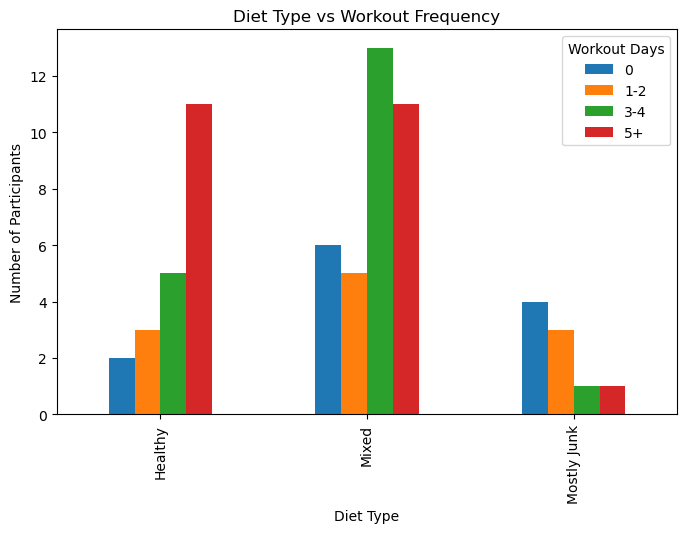

In [33]:
diet_workout.plot(kind="bar", figsize=(8,5))

plt.title("Diet Type vs Workout Frequency")
plt.xlabel("Diet Type")
plt.ylabel("Number of Participants")
plt.legend(title="Workout Days")
plt.show()

### Observation

Participants following a **Healthy** diet were more likely to report exercising **5 or more days per week**, suggesting a positive relationship between healthier eating habits and workout consistency. In contrast, respondents with a **Mostly Junk** diet were more concentrated in the lower workout frequency categories (0–2 days), indicating that poorer dietary habits may be associated with less consistent exercise. Participants following a **Mixed** diet were distributed across all workout frequencies, reflecting more varied lifestyle behaviours.

## 3. Age Group vs Workout Frequency

This analysis examines whether workout consistency differs across various age groups.

In [34]:
age_workout = pd.crosstab(df["age_group"], df["workout_days"])

age_workout

workout_days,0,1-2,3-4,5+
age_group,,,,
16-22,8,3,7,19
23-30,1,1,6,2
31-50,0,4,5,0
51+,3,3,1,2


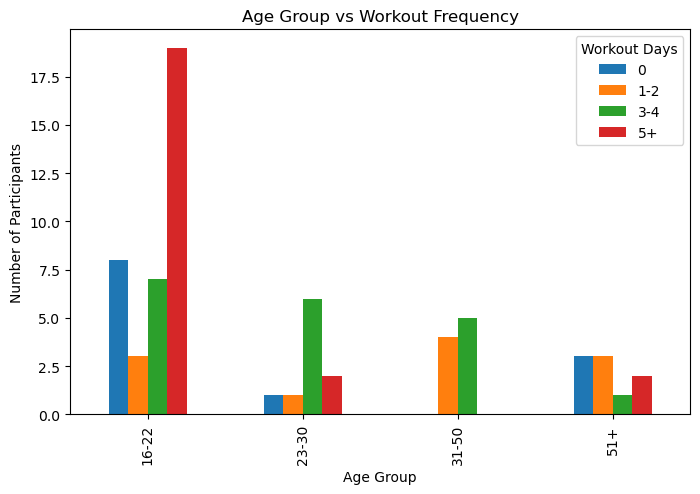

In [35]:
age_workout.plot(kind="bar", figsize=(8,5))

plt.title("Age Group vs Workout Frequency")
plt.xlabel("Age Group")
plt.ylabel("Number of Participants")
plt.legend(title="Workout Days")
plt.show()

### Observation

The **16–22** age group had the highest number of participants exercising **5 or more days per week**, indicating strong workout engagement among younger respondents. Participants aged **23–30** were primarily concentrated in the **3–4 workout days** category, while those aged **31–50** reported more moderate workout frequencies. Due to the relatively small number of respondents in the older age groups, these findings should be interpreted with caution.

## 4. Workout Skipping Behaviour vs Workout Frequency

This analysis evaluates whether participants who report skipping workouts tend to have lower workout frequency.

In [36]:
skip_workout = pd.crosstab(df["skip_workouts"], df["workout_days"])

skip_workout

workout_days,0,1-2,3-4,5+
skip_workouts,,,,
No,0,2,6,16
Yes,12,9,13,7


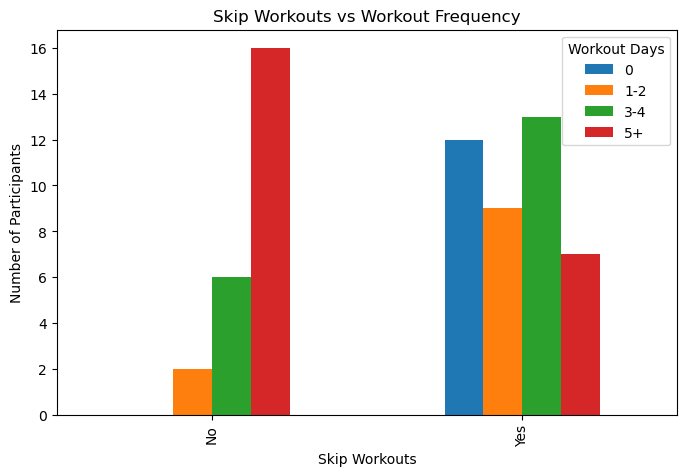

In [37]:
skip_workout.plot(kind="bar", figsize=(8,5))

plt.title("Skip Workouts vs Workout Frequency")
plt.xlabel("Skip Workouts")
plt.ylabel("Number of Participants")
plt.legend(title="Workout Days")
plt.show()

### Observation

Participants who reported **not skipping workouts** were predominantly concentrated in the **5 or more workout days per week** category, indicating strong workout consistency. In contrast, participants who reported **skipping workouts** were more frequently represented in the lower workout frequency categories (0–4 days). This suggests that regularly skipping workouts may be associated with reduced exercise consistency.

# Key Findings

Based on the exploratory data analysis, the following insights were identified:

1. The majority of survey participants belong to the **16–22** age group.

2. Most respondents reported exercising **5 or more days per week**, indicating a generally active participant group.

3. **7+ hours of sleep** was the most common sleep duration and was associated with higher workout frequency.

4. Participants following a **Healthy** diet were more likely to report exercising **5 or more days per week**, while those with a **Mostly Junk** diet were more concentrated in lower workout frequency categories.

5. **Mixed diets** were the most common dietary pattern among participants.

6. **Muscle Gain** and **General Fitness** emerged as the primary fitness goals.

7. Participants who reported **not skipping workouts** demonstrated higher workout consistency than those who reported skipping workouts.

8. The findings suggest that healthy lifestyle habits, including adequate sleep and balanced nutrition, are associated with more consistent exercise routines.

# Conclusion

This analysis explored the relationship between lifestyle habits and workout consistency using survey responses collected from 65 participants.

The findings suggest that participants who maintain healthier lifestyle habits—such as obtaining sufficient sleep and following healthier dietary patterns—generally demonstrate greater workout consistency. Although the survey sample is relatively small and cannot establish causation, the results highlight meaningful associations between daily lifestyle choices and exercise behaviour.

The insights generated from this project provide a foundation for interactive visualization in Power BI and demonstrate the application of Python for data cleaning, exploratory data analysis, and business insight generation.

# Recommendations

Based on the analysis, the following recommendations can be made:

- Aim for at least **7 hours of sleep** each night to support recovery and consistent exercise.
- Follow a balanced and nutritious diet to complement regular physical activity.
- Identify and address common barriers such as fatigue that contribute to missed workouts.
- Establish clear fitness goals to improve motivation and long-term workout consistency.
- Track lifestyle habits regularly to better understand their impact on overall fitness performance.

# End of Analysis

This notebook demonstrates the complete workflow of a data analytics project, including data collection, cleaning, exploratory data analysis, relationship analysis, and actionable insights. The cleaned dataset generated from this analysis will be used to build an interactive Power BI dashboard.